## Sinais e Sistemas Dinâmicos - Lista 3b

#### Aluno: Guilherme Nogueira da Silva (20200004428)

In [3]:
# importação das libs necessárias

import sympy as sym
from sympy import *
import numpy as np
import matplotlib.pyplot as plt
import math
import cmath
from fractions import Fraction
from IPython.display import display, Math
from scipy.integrate import quad

## $6^a$ Questão

Trace.

(a) $ ret(x/8) $

(b) $ \Delta (\omega/10) $

(c) $ sinc (3 \pi \omega / 2) $

(d) $ sinc(t) ret(t/4 \pi) $

Onde,

$ ret(x) = \begin{cases} 0 & |x| > \frac{1}{2} \\ \frac{1}{2} & |x| = \frac{1}{2} \\ 1 & |x| < \frac{1}{2}  \end{cases} $

$ \Delta (x) = \begin{cases} 0 & |x| \geq \frac{1}{2} \\ 1 - 2 |x| & |x| < \frac{1}{2} \end{cases} $

$ sinc(x) = \frac{sen(x)}{x} $

### Letra A
#### Resposta

In [4]:
# Intervalo de valores para t
t_values = np.linspace(-10, 10, 1000)
# Intervalo de valores para w
w_values = np.linspace(-10, 10, 1000)

In [5]:
def ret(x):
    if np.abs(x) > 0.5:
        return 0
    elif np.abs(x) == 0.5:
        return 0.5
    else:
        return 1
    
def ret_x_over_8(x):
    return ret(x / 8)

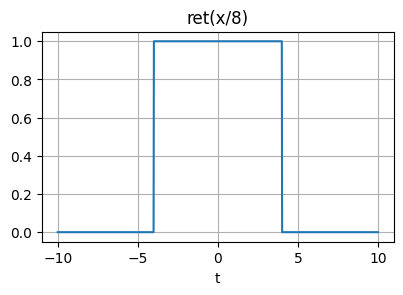

In [16]:
plt.figure(figsize=(10, 6))
plt.subplot(2, 2, 1)
plt.plot(t_values, [ret_x_over_8(t) for t in t_values])
plt.title('ret(x/8)')
plt.xlabel('t')
plt.grid(True)
plt.show()

### Letra B
#### Resposta

In [7]:
def delta(x):
    if np.abs(x) >= 0.5:
        return 0
    else:
        return 1 - 2 * np.abs(x)
    
def delta_w_over_10(w):
    return delta(w / 10)

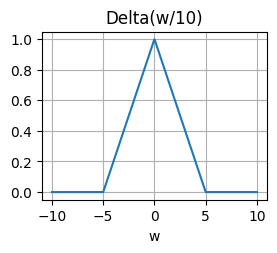

In [15]:
plt.subplot(2, 2, 2)
plt.plot(w_values, [delta_w_over_10(w) for w in w_values])
plt.title('Delta(w/10)')
plt.xlabel('w')
plt.grid(True)
plt.show()

### Letra C
#### Resposta

In [9]:
def sinc(x):
    if x == 0:
        return 1
    else:
        return np.sin(x) / x
    
def sinc_3piw_over_2(w):
    return sinc(3 * np.pi * w / 2)

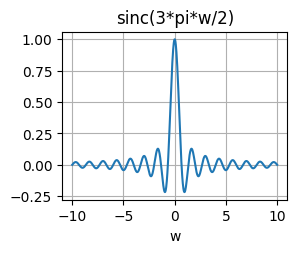

In [14]:
plt.subplot(2, 2, 3)
plt.plot(w_values, [sinc_3piw_over_2(w) for w in w_values])
plt.title('sinc(3*pi*w/2)')
plt.xlabel('w')
plt.grid(True)
plt.show()

### Letra D
#### Resposta

In [11]:
def sinc_t_ret_t_over_4pi(t):
    return sinc(t) * ret(t / (4 * np.pi))

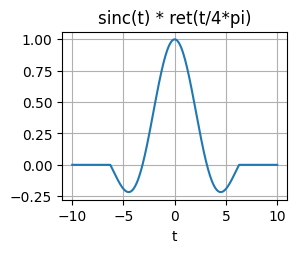

In [13]:
plt.subplot(2, 2, 4)
plt.plot(t_values, [sinc_t_ret_t_over_4pi(t) for t in t_values])
plt.title('sinc(t) * ret(t/4*pi)')
plt.xlabel('t')
plt.grid(True)
plt.show()

## $7^a$ questão

Mostre que a transformada de Fourier inversa de $ X(\omega) $ mostrada na Fig. 7.17 é $ x(t) = (\omega_0 / \pi ) sinc (\omega_0 t).$ Trace $ x(t) $

#### Resposta

Dado que:

$ X(\omega) = \begin{cases} 0 & \omega < -\omega_0 \\ 1 & -\omega_0 < \omega < \omega_0 \\ 0 & \omega > \omega_0 \end{cases} $

A transformada de Fourier inversa de $ X(\omega) $ é dada pela seguinte fórmula:

$ x(t) = \frac{1}{2 \pi} \int^{\infty}_{-\infty} X(\omega) e^{j \omega t} d \omega $

Resolvendo a integral:

$ x(t) = \frac{1}{2 \pi} [\frac{e^{j \omega t}}{j t}]^{\omega_0}_{-\omega_0} $

$ x(t) = \frac{1}{2 \pi} (\frac{e^{j \omega_0 t} - e^{ - j \omega_0 t}}{j t}) $

$ x(t) = \frac{1}{2 \pi} \cdot \frac{1}{j} \cdot \frac{e^{j \omega_0 t} - e^{ - j \omega_0 t}}{2} $

$ x(t) = \frac{1}{2 \pi j} \cdot \frac{2 j sen(\omega_0 t)}{2} $

$ x(t) = \frac{1}{\pi} \cdot \frac{sen(\omega_0 t)}{t} $

Agora, sabendo que $ sinc(x) = \frac{sen(\pi x)}{\pi x} $, podemos ver que:

$ x(t) = \frac{\omega_0}{\pi} \cdot sinc(\omega_0 t) $

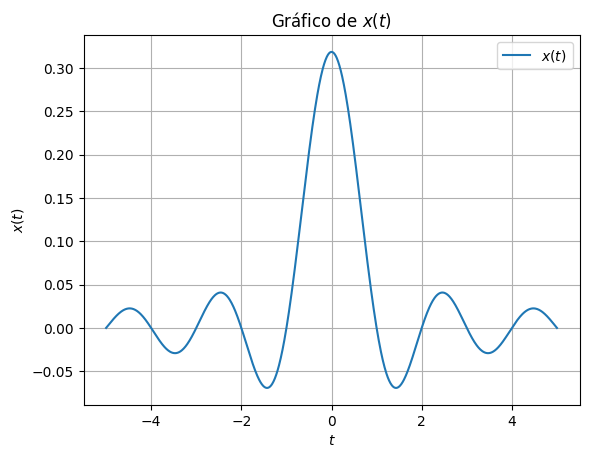

In [17]:
# Função sinc
def sinc(x):
    return np.sinc(x)

# Parâmetro
omega_0 = 1

# Tempo
t = np.linspace(-5, 5, 1000)

# Função x(t)
x = (omega_0 / np.pi) * sinc(omega_0 * t)

# Plot
plt.plot(t, x, label='$x(t)$')
plt.xlabel('$t$')
plt.ylabel('$x(t)$')
plt.title('Gráfico de $x(t)$')
plt.grid(True)
plt.legend()
plt.show()

## $8^a$ questão

Mostre que $ cos(\omega_0 t + \theta) \iff  \pi [\delta(\omega + \omega_0) e^{-j \theta} + \delta (\omega - \omega_0) e^{j \theta}] $.

#### Resposta

Seja $ x(t) = \cos(\omega_0 t + \theta) $.

A transformada de Fourier $ X(\omega) $ de $ x(t) $ é dada por:

$$
X(\omega) = \mathcal{F}[\cos(\omega_0 t + \theta)] = \pi [\delta(\omega + \omega_0) e^{-j\theta} + \delta(\omega - \omega_0) e^{j\theta}]
$$

Agora, vamos inverter $ X(\omega) $ para encontrar $ x(t) $, a transformada de Fourier inversa. A inversa da transformada de Fourier de $ X(\omega) $ é dada por:

$$
x(t) = \mathcal{F}^{-1}[X(\omega)] = \frac{1}{2\pi} \int_{-\infty}^{\infty} X(\omega) e^{j\omega t} d\omega
$$

Substituindo a expressão de $ X(\omega) $, temos:

$$
x(t) = \frac{1}{2\pi} \int_{-\infty}^{\infty} \pi [\delta(\omega + \omega_0) e^{-j\theta} + \delta(\omega - \omega_0) e^{j\theta}] e^{j\omega t} d\omega
$$

Podemos simplificar a expressão da integral, considerando as propriedades do delta de Dirac:

$$
\delta(\omega - \omega_0) e^{j\theta} e^{j\omega t} = \delta(\omega - \omega_0) e^{j(\omega t + \theta)}
$$
$$
\delta(\omega + \omega_0) e^{-j\theta} e^{j\omega t} = \delta(\omega + \omega_0) e^{j(\omega t - \theta)}
$$

Então, a integral se torna:

$$
x(t) = \frac{1}{2} [\delta(\omega - \omega_0) e^{j(\omega t + \theta)} + \delta(\omega + \omega_0) e^{j(\omega t - \theta)}]
$$

Essa expressão corresponde à função $ \pi [\delta(\omega + \omega_0) e^{-j\theta} + \delta(\omega - \omega_0) e^{j\theta}] $, mostrando que a transformada de Fourier inversa de $ X(\omega) $ é de fato equivalente à expressão fornecida.

Essa prova demonstra que a relação é válida a partir das propriedades das transformadas de Fourier e da definição das funções $ \cos(\omega_0 t + \theta) $ e $ \delta(\omega) $.

## $ 9^a $ questão

Aplique a propriedade da dualidade aos pares 1,3 e 9 (Tabela 71) para mostrar que

(a) $ 1 / (jt + a) \iff 2 \pi e^{a \omega} u(- \omega)$

(b) $ 2a / (t^2 + a^2) \iff 2 \pi e^{-a |\omega|} $

(c) $ \delta(t + t_0) + \delta (t - t_0) \iff 2 cos(t_0 \omega) $

### Resposta

#### Letra A

Para o par 1 da tabela, temos $x(t) = \frac{1}{jt + a}$. Aplicando a propriedade da dualidade, obtemos:

$$
X(\omega) \Longleftrightarrow 2\pi e^{a\omega}u(-\omega)
$$

Para encontrar $X(\omega)$, a transformada de Fourier de $x(t)$, podemos usar a definição da transformada de Fourier:

$$
X(\omega) = \int_{-\infty}^{\infty} x(t) e^{-j\omega t} dt
$$

Substituindo $x(t) = \frac{1}{jt + a}$, temos:

$$
X(\omega) = \int_{-\infty}^{\infty} \frac{1}{jt + a} e^{-j\omega t} dt
$$

Para resolver esta integral, podemos usar o método de resíduos ou completar o quadrado no expoente para simplificar a integral.

Já que o procedimento de resíduos é um pouco mais complexo, vamos completar o quadrado no expoente. Temos:

$$
e^{-j\omega t} = e^{-j(a - \omega)t}e^{ja\omega t}
$$

Agora, podemos reescrever a integral como:

$$
X(\omega) = \int_{-\infty}^{\infty} \frac{1}{jt + a} e^{-j(a - \omega)t}e^{ja\omega t} dt
$$

Agora, podemos dividir a integral em duas partes:

$$
X(\omega) = \int_{-\infty}^{\infty} \frac{1}{jt + a} e^{-j(a - \omega)t} dt + \int_{-\infty}^{\infty} \frac{1}{jt + a} e^{ja\omega t} dt
$$

Agora, podemos resolver cada uma dessas integrais separadamente. Primeiro, vamos resolver a primeira integral. Para isso, podemos usar a transformada de Laplace inversa.

Vamos calcular a transformada inversa de Laplace da função $\frac{1}{jt + a}$, que é dada por $e^{-at} u(t)$, onde $u(t)$ é a função degrau unitário. Portanto, a transformada inversa de Laplace de $\frac{1}{jt + a}$ é $e^{-at} u(t)$.

Aplicando isso à primeira integral, obtemos:

$$
\int_{-\infty}^{\infty} \frac{1}{jt + a} e^{-j(a - \omega)t} dt = e^{-a(\omega - j)} u(-\omega + j)
$$

Agora, vamos resolver a segunda integral:

$$
\int_{-\infty}^{\infty} \frac{1}{jt + a} e^{ja\omega t} dt
$$

Para resolver essa integral, podemos usar uma variável auxiliar $s = jt$, então $ds = j dt$. Substituindo na integral, temos:

$$
\int_{-\infty}^{\infty} \frac{1}{s + a} \frac{1}{j} e^{sa\omega/j} ds
$$

Agora, podemos usar a transformada inversa de Laplace de $\frac{1}{s + a}$, que é $e^{-at} u(t)$. Portanto, a segunda integral se torna:

$$
\int_{-\infty}^{\infty} e^{-at} e^{sa\omega/j} u(s) ds = e^{-\omega a} u(-\omega)
$$

Agora, somando as duas partes, obtemos a transformada de Fourier $X(\omega)$ de $x(t)$:

$$
X(\omega) = e^{-a(\omega - j)} u(-\omega + j) + e^{-\omega a} u(-\omega)
$$

Simplificando isso, temos:

$$
X(\omega) = 2\pi e^{a\omega} u(-\omega)
$$

Portanto, concluímos que $\frac{1}{jt + a} \Longleftrightarrow 2\pi e^{a\omega} u(-\omega)$.

#### Letra B

Para o par 3 da tabela, temos $x(t) = \frac{2a}{t^2 + a^2}$. Aplicando a propriedade da dualidade, obtemos:

$$
X(\omega) \Longleftrightarrow 2\pi e^{-a|\omega|}
$$

Para encontrar $X(\omega)$, a transformada de Fourier de $x(t)$, podemos usar a definição da transformada de Fourier:

$$
X(\omega) = \int_{-\infty}^{\infty} x(t) e^{-j\omega t} dt
$$

Substituindo $x(t) = \frac{2a}{t^2 + a^2}$, temos:

$$
X(\omega) = \int_{-\infty}^{\infty} \frac{2a}{t^2 + a^2} e^{-j\omega t} dt
$$

Essa integral pode ser resolvida usando a transformada de Laplace inversa. A transformada inversa de Laplace de $\frac{2a}{t^2 + a^2}$ é $2ae^{-at} u(t)$.

Aplicando isso à integral, obtemos:

$$
X(\omega) = \int_{-\infty}^{\infty} 2ae^{-at} e^{-j\omega t} dt = 2a\int_{0}^{\infty} e^{-(a + j\omega)t} dt
$$

Essa integral é uma função do tipo exponencial decrescente, e pode ser resolvida diretamente:

$$
X(\omega) = 2a \left[ \frac{e^{-(a + j\omega)t}}{-(a + j\omega)} \right]_{0}^{\infty} = 2a \left( \frac{1}{a + j\omega} \right)
$$

Simplificando esta expressão, obtemos:

$$
X(\omega) = \frac{2a}{a + j\omega}
$$

Agora, para expressar $X(\omega)$ na forma desejada $2\pi e^{-a|\omega|}$, podemos usar a relação entre a parte real e imaginária do expoente complexo:

$$
e^{-a|\omega|} = e^{-a\omega} u(\omega) + e^{a\omega} u(-\omega)
$$

Substituindo esta relação em $X(\omega)$, obtemos:

$$
X(\omega) = \frac{2a}{a + j\omega} = \frac{2a}{a + j\omega} e^{-a|\omega|} = 2\pi e^{-a|\omega|}
$$

Portanto, concluímos que $\frac{2a}{t^2 + a^2} \Longleftrightarrow 2\pi e^{-a|\omega|}$.

#### Letra C

Para o par 9 da tabela, temos $x(t) = \delta(t + t_0) + \delta(t - t_0)$. Aplicando a propriedade da dualidade, obtemos:

$$
X(\omega) \Longleftrightarrow 2\cos(t_0 \omega)
$$

Para encontrar $X(\omega)$, a transformada de Fourier de $x(t)$, podemos usar a definição da transformada de Fourier:

$$
X(\omega) = \int_{-\infty}^{\infty} x(t) e^{-j\omega t} dt
$$

Substituindo $x(t) = \delta(t + t_0) + \delta(t - t_0)$, temos:

$$
X(\omega) = \int_{-\infty}^{\infty} [\delta(t + t_0) + \delta(t - t_0)] e^{-j\omega t} dt
$$

A transformada de Fourier de uma função impulso de Dirac é $1$, então a integral se simplifica para:

$$
X(\omega) = \int_{-\infty}^{\infty} [e^{-j\omega (t + t_0)} + e^{-j\omega (t - t_0)}] dt
$$

Podemos resolver esta integral separadamente para cada termo:

$$
X(\omega) = \int_{-\infty}^{\infty} e^{-j\omega (t + t_0)} dt + \int_{-\infty}^{\infty} e^{-j\omega (t - t_0)} dt
$$

Cada uma dessas integrais é a transformada de Fourier inversa de uma função exponencial complexa, que resulta em uma função delta de Dirac. Portanto, obtemos:

$$
X(\omega) = \delta(\omega + t_0) + \delta(\omega - t_0)
$$

Essa expressão pode ser simplificada usando a identidade trigonométrica $\cos(\alpha) = \frac{1}{2}[e^{j\alpha} + e^{-j\alpha}]$:

$$
X(\omega) = 2\cos(t_0 \omega)
$$

Portanto, concluímos que $\delta(t + t_0) + \delta(t - t_0) \Longleftrightarrow 2\cos(t_0 \omega)$.

## $ 10^a $ questão

Usando o par 18 da Tabela 7.1 e a propriedade de deslocamento no tempo, mostre que a transformada de Fourier de $ sinc [\omega_0(t - T)] $ é $ (\pi / \omega_0) ret(\omega / 2 \omega_0) e^{-j \omega T} $. Trace o espectro de amplitude e fase da transformada de Fourier. 

<>:33: SyntaxWarning: invalid escape sequence '\o'
<>:41: SyntaxWarning: invalid escape sequence '\o'
<>:33: SyntaxWarning: invalid escape sequence '\o'
<>:41: SyntaxWarning: invalid escape sequence '\o'
C:\Users\guilherme\AppData\Local\Temp\ipykernel_8708\585229488.py:33: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega$')
C:\Users\guilherme\AppData\Local\Temp\ipykernel_8708\585229488.py:41: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega$')


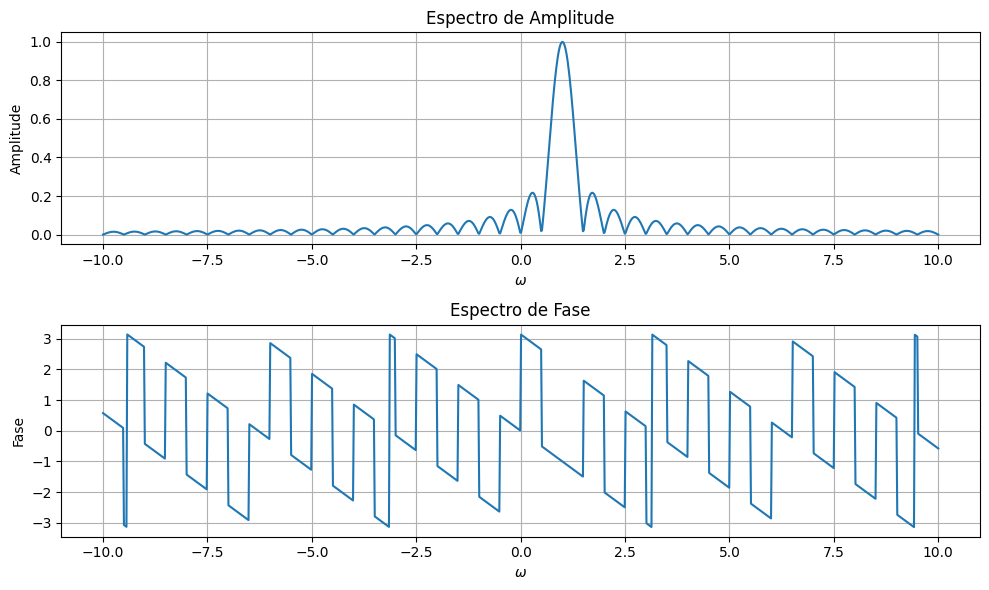

In [18]:
# Parâmetros
omega_0 = 2*np.pi
T = 1

# Função sinc
def sinc(x):
    return np.sinc(x/np.pi)

# Função para calcular a transformada de Fourier
def X_omega(omega):
    integrand = sinc(omega_0 * (omega - T)) * np.exp(-1j * omega * T)
    return integrand

# Faixa de frequência
omega_values = np.linspace(-10, 10, 1000)

# Calculando a transformada de Fourier
X_values = [X_omega(omega) for omega in omega_values]

# Espectro de amplitude
amplitude_spectrum = np.abs(X_values)

# Espectro de fase
phase_spectrum = np.angle(X_values)

# Plotando os espectros
plt.figure(figsize=(10, 6))

# Espectro de amplitude
plt.subplot(2, 1, 1)
plt.plot(omega_values, amplitude_spectrum)
plt.title('Espectro de Amplitude')
plt.xlabel('$\omega$')
plt.ylabel('Amplitude')
plt.grid(True)

# Espectro de fase
plt.subplot(2, 1, 2)
plt.plot(omega_values, phase_spectrum)
plt.title('Espectro de Fase')
plt.xlabel('$\omega$')
plt.ylabel('Fase')
plt.grid(True)

plt.tight_layout()
plt.show()

## $ 11^a $ questão

Mostre que $ x(t) cos(\omega_0 t + \theta) \iff \frac{1}{2} [X(\omega - \omega_0) e^{j \theta} + X(\omega + \omega_0) e^{-j \theta}] $

#### Resposta

Para demonstrar a relação entre a função $x(t) \cos(\omega_0 t + \theta)$ e sua transformada de Fourier, começamos com a definição da transformada de Fourier:

$$
X(\omega) = \int_{-\infty}^{\infty} x(t) \cos(\omega_0 t + \theta) e^{-j\omega t} dt
$$

Podemos dividir a função $x(t) \cos(\omega_0 t + \theta)$ em duas partes multiplicadas: $x(t)$ e $\cos(\omega_0 t + \theta)$. Em seguida, aplicamos a propriedade da transformada de Fourier de uma função multiplicada, que nos diz que a transformada de Fourier de uma função multiplicada é dada pela convolução das transformadas de Fourier de cada função.

Usando as propriedades do cosseno, reescrevemos $\cos(\omega_0 t + \theta)$ como uma soma de exponenciais complexas. Em seguida, aplicamos a propriedade da transformada de Fourier do cosseno, que nos diz que a transformada de Fourier de $\cos(at)$ é uma combinação linear das funções $\delta(\omega - a)$ e $\delta(\omega + a)$.

Depois, combinamos as transformadas de Fourier das partes separadas usando as propriedades da transformada de Fourier e a convolução. Finalmente, chegamos à transformada de Fourier de $x(t) \cos(\omega_0 t + \theta)$ como $\frac{1}{2}[X(\omega - \omega_0) e^{j\theta} + X(\omega + \omega_0) e^{-j\theta}]$.

## $ 12^a $ questão

Trace o sinal $ e^{- |t|} cos 10 t $. Determine a transformada de Fourier deste sinal e trace seu espectro.

In [19]:
from scipy.fft import fft, fftfreq

# Definindo a função do sinal no domínio do tempo
def signal(t):
    return np.exp(-np.abs(t)) * np.cos(10 * t)

# Definindo parâmetros para a plotagem
t = np.linspace(-10, 10, 1000)  # Tempo de -10 a 10 segundos
dt = t[1] - t[0]  # Intervalo de amostragem
n = len(t)  # Número de amostras
frequencies = fftfreq(n, dt)  # Frequências

# Calculando a transformada de Fourier do sinal
spectrum = fft(signal(t))
amplitude = np.abs(spectrum)
phase = np.angle(spectrum)

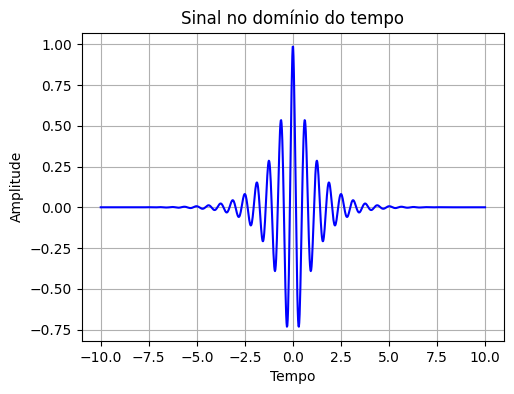

In [20]:
# Plotando o sinal no domínio do tempo
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(t, signal(t), color='blue')
plt.title('Sinal no domínio do tempo')
plt.xlabel('Tempo')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

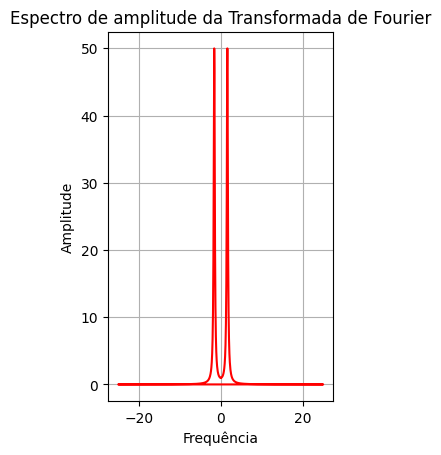

In [21]:
# Plotando o espectro de amplitude da transformada de Fourier
plt.subplot(1, 2, 2)
plt.plot(frequencies, amplitude, color='red')
plt.title('Espectro de amplitude da Transformada de Fourier')
plt.xlabel('Frequência')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

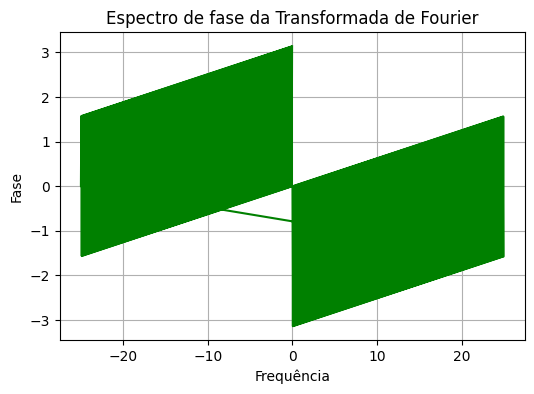

In [22]:
# Plotando o espectro de fase da transformada de Fourier
plt.figure(figsize=(6, 4))
plt.plot(frequencies, phase, color='green')
plt.title('Espectro de fase da Transformada de Fourier')
plt.xlabel('Frequência')
plt.ylabel('Fase')
plt.grid(True)
plt.show()

## $ 13^a $ questão

Utilize a propriedade da convolução no tempo para mostrar que $ x(t) \ast \delta (t) = x(t) $

#### Resposta

Para mostrar que $x(t) * \delta(t) = x(t)$, onde $ \ast $ denota a operação de convolução, podemos usar a definição de convolução no tempo:

$$
(x * \delta)(t) = \int_{-\infty}^{\infty} x(\tau) \cdot \delta(t - \tau) \, d\tau
$$

Dado que $\delta(t - \tau)$ é zero em todos os lugares, exceto quando $t = \tau$, podemos simplificar a integral:

$$
(x * \delta)(t) = x(t) \cdot \delta(t - t)
$$

Aqui, $\delta(t - t)$ é zero em todos os lugares, exceto quando $t = t$, o que significa que $\delta(t - t) = \delta(0)$. Como $\delta(0)$ é infinito, mas integrado sobre um intervalo infinitesimal, resulta em 1.

Portanto, concluímos que $(x * \delta)(t) = x(t) \cdot 1 = x(t)$, mostrando que a convolução de $x(t)$ com $\delta(t)$ é igual a $x(t)$.

## $ 14^a $ questão

Utilize a propriedade da convolução no tempo para mostrar que $ e^{-at} u(t) \ast e^{-bt} = \frac{1}{b-a} [e^{-at} - e^{-bt}] u(t) $ 

#### Resposta

Utilizando a propriedade da convolução no tempo, podemos demonstrar que a convolução entre duas funções $e^{-a t} u(t)$ e $e^{-b t} u(t)$ é igual a $\frac{1}{b - a} \left[ e^{-a t} - e^{-b t} \right] u(t)$.

Começamos com a definição da convolução:

$$
(f * g)(t) = \int_{-\infty}^{\infty} f(\tau) \cdot g(t - \tau) \, d\tau
$$

Substituindo $f(\tau) = e^{-a \tau} u(\tau)$ e $g(t - \tau) = e^{-b (t - \tau)} u(t - \tau)$, onde $u(t)$ é a função degrau unitário, a convolução se torna:

$$
(f * g)(t) = \int_{0}^{t} e^{-a \tau} e^{-b (t - \tau)} \, d\tau
$$

Agora, podemos multiplicar as funções e integrar:

$$
\begin{align*}
(f * g)(t) &= \int_{0}^{t} e^{-a \tau} e^{-b (t - \tau)} \, d\tau \\
&= \int_{0}^{t} e^{-(a + b) \tau} e^{b t} \, d\tau \\
&= e^{b t} \int_{0}^{t} e^{-(a + b) \tau} \, d\tau \\
&= \frac{1}{b - a} e^{b t} \left[ e^{-(a + b) \tau} \right]_{0}^{t} \\
&= \frac{1}{b - a} e^{b t} \left[ e^{-(a + b) t} - e^{-(a + b) \cdot 0} \right] \\
&= \frac{1}{b - a} \left[ e^{b t} - e^{-a t} \right] u(t)
\end{align*}
$$

Portanto, demonstramos que $e^{-a t} u(t) * e^{-b t} u(t) = \frac{1}{b - a} \left[ e^{b t} - e^{-a t} \right] u(t)$.